# Riesgo Crediticio

# Definicion de variables

| Feature Name                 | Descripción / Traducción                               |
|------------------------------|--------------------------------------------------------|
| person_age                   | Edad                                                   |
| person_income                | Ingreso Anual                                          |
| person_home_ownership        | Tenencia de Vivienda                                   |
| person_emp_length          | Tiempo de Empleo (en años)  2.7% nulls                           |
| loan_intent                  | Propósito del Préstamo                                 |
| loan_grade                   | Calificación del Préstamo                              |
| loan_amnt                    | Monto del Préstamo                                     |
| loan_int_rate                | Tasa de Interés                                        |
| loan_status                  | Estado del Préstamo (0 es No Incumplimiento, 1 es Incumplimiento) |
| loan_percent_income          | Porcentaje del Ingreso                                 |
| cb_person_default_on_file    | Incumplimiento Histórico                               |
| cb_preson_cred_hist_length   | Historial Crediticio (Longitud)                        |

# 1. Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import plotly.express as px

## 1.1 Creacion de funciones

In [2]:
def infoOutlaier(dataset,columna):
    Q1 = dataset[columna].quantile(0.25)
    Q3 = dataset[columna].quantile(0.75)

    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = dataset[
        (dataset[columna] < lim_inf) | 
        (dataset[columna] > lim_sup)
    ]
    print(f'Q1: {Q1:,.1f}')
    print(f'Q3: {Q3:,.1f}')
    print(f'LimInf: {lim_inf:,.1f}')
    print(f'LimSup: {lim_sup:,.1f}')
    display(outliers.sort_values(by=columna, ascending=False))

In [3]:
# Analisis de riesgo por segmento
def calLift (nameDf,nameColumn):
    nameVar = ( 
    nameDf
    .groupby(nameColumn,observed=True)
    .agg(
        total=('loan_status', 'count'),
        defaults=('loan_status', 'sum'),
        default_rate=('loan_status', 'mean')
        )
    )


    nameVar['lift'] = ( 
        nameVar['default_rate'] /
        nameDf['loan_status'].mean()
    )
    nameVar = nameVar.reset_index().sort_values(by='lift')
    return nameVar

Se cambia el formato global de pandas, para que no aparesca en notacion cientifica.

In [4]:
import pandas as pd

pd.options.display.float_format = '{:,.2f}'.format


# 2. Cargar el dataset

In [5]:
df = pd.read_csv('../Data/credit_risk_dataset.csv')

# 3. EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df.head(2).T

,0,1
person_age,22,21
person_income,59000,9600
person_home_ownership,RENT,OWN
person_emp_length,123.00,5.00
loan_intent,PERSONAL,EDUCATION
loan_grade,D,B
loan_amnt,35000,1000
loan_int_rate,16.02,11.14
loan_status,1,0
loan_percent_income,0.59,0.10


In [8]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,"32,581.00","32,581.00","31,686.00","32,581.00","29,465.00","32,581.00","32,581.00","32,581.00"
mean,27.73,"66,074.85",4.79,"9,589.37",11.01,0.22,0.17,5.80
std,6.35,"61,983.12",4.14,"6,322.09",3.24,0.41,0.11,4.06
min,20.00,"4,000.00",0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,"38,500.00",2.00,"5,000.00",7.90,0.00,0.09,3.00
50%,26.00,"55,000.00",4.00,"8,000.00",10.99,0.00,0.15,4.00
75%,30.00,"79,200.00",7.00,"12,200.00",13.47,0.00,0.23,8.00
max,144.00,"6,000,000.00",123.00,"35,000.00",23.22,1.00,0.83,30.00


## 3.1 Evaluacion de Null y NaN

In [9]:
dfNulls = df.isnull().sum()
dfNulls

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [10]:
for idx,var in dfNulls.items():
    porc = (var*100)/df.shape[0]
    if porc != 0:
        print(f'{idx}: {porc:.1f}%')

person_emp_length: 2.7%
loan_int_rate: 9.6%


* Las variableas encontradas con valores nulos, son las siguientes:
    * **person_emp_length:** 2.7%
    * **loan_int_rate:** 9.6%

## 3.2 Evaluacion de outlier

### 3.2.1 Revision de la variable Edad

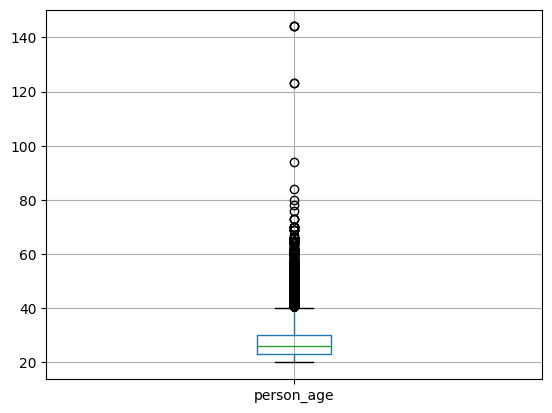

In [11]:
df.boxplot(column='person_age')
plt.show()


In [12]:
infoOutlaier(df,'person_age')

Q1: 23.0
Q3: 30.0
LimInf: 12.5
LimSup: 40.5


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32297,144,6000000,MORTGAGE,12.00,PERSONAL,C,5000,12.73,0,0.00,N,25
81,144,250000,RENT,4.00,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.00,EDUCATION,B,6000,11.86,0,0.03,N,2
747,123,78000,RENT,7.00,VENTURE,B,20000,NaN,0,0.26,N,4
575,123,80004,RENT,2.00,EDUCATION,B,20400,10.25,0,0.25,N,3
...,...,...,...,...,...,...,...,...,...,...,...,...
29271,41,60000,RENT,7.00,HOMEIMPROVEMENT,A,23800,6.91,1,0.40,N,15
29176,41,49000,RENT,4.00,HOMEIMPROVEMENT,E,25000,17.04,1,0.51,N,13
29133,41,480000,MORTGAGE,3.00,DEBTCONSOLIDATION,A,16000,7.90,0,0.03,N,17
29188,41,200000,MORTGAGE,2.00,VENTURE,B,1000,10.38,0,0.01,N,13


 **Identificación de valores atípicos (IQR)**
* A partir del diagrama de caja y del cálculo del rango intercuartílico (IQR), se obtuvo un límite inferior de 12.5 y un límite superior de 40.5. 
* Esto indica que cualquier edad superior a 40.5 puede considerarse un valor atípico desde el punto de vista estadístico, ya que la mayoría de los clientes históricos se concentra entre los 23 y 30 años. 
* Sin embargo, es importante aclarar que un valor atípico no necesariamente implica un error en los datos, sino simplemente una menor frecuencia dentro de la distribución.

**Detección de valores inconsistentes con la realidad del negocio**

* Dentro de los valores superiores al límite estadístico, se identificaron edades extremadamente altas (por ejemplo, mayores a 120 años), las cuales no son coherentes con el contexto del estudio.

* Dado que se trata de un dataset sintético, es probable que estos valores hayan sido generados de manera aleatoria o errónea.

* Por esta razón, se decidió eliminar aquellas edades que superen un umbral realista (por ejemplo, 120 a 144 años), con el objetivo de preservar la calidad del análisis y evitar distorsiones en futuras etapas como modelado predictivo.



### 3.2.2 Revision de la variable de antiguedad laboral

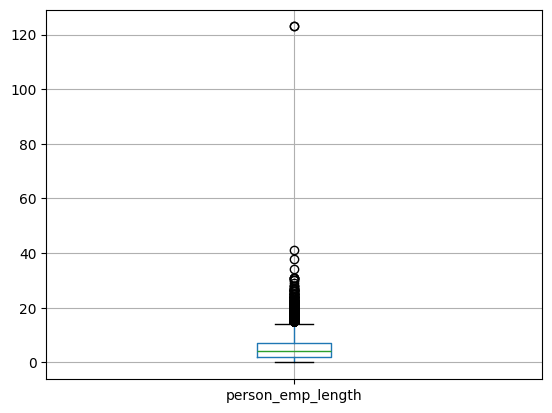

In [13]:
df.boxplot(column='person_emp_length')
plt.show()

In [14]:
infoOutlaier(df,'person_emp_length')

Q1: 2.0
Q3: 7.0
LimInf: -5.5
LimSup: 14.5


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.00,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.00,VENTURE,A,20000,6.54,0,0.10,N,4
32355,78,48000,RENT,41.00,MEDICAL,A,3000,7.51,0,0.06,N,25
32515,53,106000,MORTGAGE,38.00,PERSONAL,B,20000,9.88,0,0.19,N,23
32428,58,49000,MORTGAGE,34.00,MEDICAL,D,7500,13.55,1,0.15,Y,24
...,...,...,...,...,...,...,...,...,...,...,...,...
20038,35,62217,RENT,15.00,EDUCATION,A,3700,NaN,0,0.06,N,8
20014,33,74400,RENT,15.00,DEBTCONSOLIDATION,C,3600,15.27,0,0.05,N,9
19994,32,48000,RENT,15.00,DEBTCONSOLIDATION,A,3600,6.92,0,0.07,N,5
19942,31,34000,RENT,15.00,PERSONAL,C,10625,14.79,1,0.31,Y,6


In [15]:
df[df['person_emp_length']>= df['person_age'] ]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.00,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.00,VENTURE,A,20000,6.54,0,0.10,N,4


* Dado que el límite inferior resulta negativo, se descarta su interpretación práctica, ya que no es posible tener años laborales menores a cero.

* Desde el punto de vista estadístico, valores superiores a 14.5 años pueden considerarse atípicos. Sin embargo, no todos los valores atípicos representan errores en los datos.

* Se identificaron registros con más de 100 años de experiencia laboral, lo cual no es coherente con la realidad del negocio. Debido a que el dataset es sintético, es probable que estos valores hayan sido generados de forma aleatoria.

**Por esta razón, se decidió:**

1. Eliminar registros con años de experiencia superiores a un umbral realista.

2. Eliminar registros donde los años de experiencia superen la edad del individuo, ya que representan inconsistencias lógicas.

## 3.3 Creacion de Mask y Nuevo df

In [16]:
mask = (
    (df['person_age'] < 100) &
    (df['person_emp_length'] < df['person_age']) |
    (df['person_emp_length'].isna())
)

newDf = df[mask].copy()


## 3.4 Analisis de correlacion de variables

In [17]:
df_numeric = newDf.select_dtypes(include=['number'])
corr_matrix = df_numeric.corr(method='spearman')
corr_matrix



,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.00,0.14,0.11,0.06,0.01,-0.03,-0.06,0.81
person_income,0.14,1.00,0.21,0.41,-0.03,-0.27,-0.37,0.09
person_emp_length,0.11,0.21,1.00,0.11,-0.07,-0.10,-0.06,0.07
loan_amnt,0.06,0.41,0.11,1.00,0.11,0.08,0.65,0.04
loan_int_rate,0.01,-0.03,-0.07,0.11,1.00,0.32,0.12,0.01
loan_status,-0.03,-0.27,-0.10,0.08,0.32,1.00,0.32,-0.02
loan_percent_income,-0.06,-0.37,-0.06,0.65,0.12,0.32,1.00,-0.04
cb_person_cred_hist_length,0.81,0.09,0.07,0.04,0.01,-0.02,-0.04,1.00


* La matriz de correlación muestra que las variables con mayor asociación con la variable objetivo (loan_status) son:

1. Tasa de interés (loan_int_rate) con un coeficiente de 0.32.
2. Porcentaje del ingreso destinado al préstamo (loan_percent_income) con 0.32.
3. Ingreso anual (person_income) con -0.27, indicando una relación inversa entre ingreso y probabilidad de incumplimiento.

# 4. Analisis de registros 

## 4.1 Analisis del estado de los prestamos

In [18]:
import plotly.express as px

px.defaults.template = "presentation"

counts = newDf['loan_status'].value_counts().reset_index()
counts.columns = ['loan_status', 'count']

counts['percentage'] = counts['count'] / counts['count'].sum() * 100
counts['estado'] = counts['loan_status'].map({
    0: 'Sin incumplimiento',
    1: 'Con incumplimiento'
})

fig = px.bar(
    counts,
    x='estado',
    y='count',
    title='Cantidad de préstamos por estado',
    labels={'estado': 'Estado del préstamo', 'count': 'Cantidad de préstamos'},
    
)

fig.update_traces(
    hovertemplate=
    "<b>Estado:</b> %{x}<br>" +
    "<b>Cantidad de préstamos:</b> %{y:,.0f}<br>" +
    "<b>Porcentaje:</b> %{customdata[0]:.2f}%<extra></extra>",
    customdata=counts[['percentage']]
)

fig.show()

![Distribución Loan Status](../Img/01.png)

* El análisis del registro de préstamos muestra que el 78,18% (25.467) de los clientes cumplieron con su obligación crediticia, mientras que el 21,82% (7.017) incurrió en incumplimiento.

* Esto indica que aproximadamente uno de cada cinco préstamos presenta riesgo, lo que evidencia una tasa de incumplimiento significativa dentro del portafolio.

## 4.2 Analisis del estado del préstamo en clientes con antecedentes de incumplimiento

In [19]:
df_plot = newDf.groupby('cb_person_default_on_file')['loan_status'].value_counts().reset_index(name='count')

df_plot["total_group"] = df_plot.groupby("cb_person_default_on_file")["count"].transform("sum")


df_plot["percentage"] = df_plot["count"] / df_plot["total_group"]


df_plot["loan_status_label"] = df_plot["loan_status"].map({
    0: "Cumplió",
    1: "Incumplió"
})

df_plot["historial_label"] = df_plot["cb_person_default_on_file"].map({
    "N": "Sin historial",
    "Y": "Con historial"
})


fig = px.bar(
    df_plot,
    x="historial_label",
    y="count",
    color="loan_status_label",
    barmode="group",
    custom_data=["percentage", "loan_status_label", "historial_label"],
    labels={
        "historial_label": "Historial de Incumplimiento",
        "count": "Cantidad de préstamos",
        "loan_status_label": "Estado del préstamo",
    },
    title="Incumplimiento según historial crediticio"
)

fig.update_traces(
    hovertemplate=
    "<b>Historial:</b> %{customdata[2]}<br>" +
    "<b>Estado del préstamo:</b> %{customdata[1]}<br>" +
    "<b>Cantidad:</b> %{y}<br>" +
    "<b>Porcentaje dentro del grupo:</b> %{customdata[0]:.2%}<extra></extra>"
)



fig.show()

![Historial vs Default](../Img/02.png)

* El análisis evidencia que los clientes sin historial previo de incumplimiento presentan una tasa de incumplimiento del 18,4%, mientras que aquellos con antecedentes alcanzan una tasa del 37,8%.

* Esto implica que el riesgo de no pagar el préstamo es del doble en clientes con historial negativo, lo que confirma la importancia explicativa de esta variable.

## 4.3 Evaluacion de la tasa de interes

In [20]:
newDf['rate_pct_bin'] = pd.qcut(
    newDf['loan_int_rate'],
    q=5,
    duplicates='drop'
)

newDf['rate_pct_bin'] = newDf['rate_pct_bin'].cat.add_categories('Missing')
newDf['rate_pct_bin'] = newDf['rate_pct_bin'].fillna('Missing')

dfIntRate = calLift(newDf,'rate_pct_bin')
dfIntRate['rate_pct_bin'] = dfIntRate['rate_pct_bin'].astype(str)

In [21]:
fig = px.bar(
    dfIntRate,
    x='rate_pct_bin',
    y='default_rate',
    labels={
        "rate_pct_bin": "Tasas de interes",
        "default_rate": "Riesgo de incumplimiento",
    },
    title="Riesgo de Incumplimiento según Tasa de Interés"
    
)

fig.update_layout(
    xaxis=dict(
        tickmode='array',
        tickvals=['(5.419, 7.51]', '(7.51, 10.25]', '(10.25, 11.86]','(11.86, 13.92]','Missing','(13.92, 23.22]'],
        ticktext=['7.5%', '10.2%', '11.8%','13.9%','Valores Perdidos','23.2%'] # lo que quieres mostrar
    ),
    yaxis=dict(
        tickformat=".0%"
    )
)

fig.show()

![Riesgo por Tasa](../Img/tasaInteres.png)

* Se observa una relación positiva entre la tasa de interés y la tasa de incumplimiento: a medida que aumenta la tasa aplicada al préstamo, también se incrementa la probabilidad de incumplir. El segmento con tasas superiores al 23.2% presenta la mayor tasa de incumplimiento, alcanzando aproximadamente un 51%, lo que evidencia una fuerte concentración de riesgo en este grupo.

* Adicionalmente, los registros con información faltante muestran una tasa de incumplimiento cercana al 21%, lo que representa un nivel significativo de exposición y sugiere la necesidad de analizar con mayor profundidad las causas asociadas a este segmento.

## 4.4 Analisis del porcentaje del ingreso

In [22]:
newDf['percentIncome_pct_bin'] = pd.qcut(
    newDf['loan_percent_income'],
    q=5,
    duplicates='drop'
)


dfPercentIncome = calLift(newDf,'percentIncome_pct_bin')
dfPercentIncome['percentIncome_pct_bin'] = dfPercentIncome['percentIncome_pct_bin'].astype(str)

In [23]:
fig = px.bar(
    dfPercentIncome,
    x='percentIncome_pct_bin',
    y='default_rate',
    labels={
        "percentIncome_pct_bin": "Porcentaje del ingreso",
        "default_rate": "Riesgo de incumplimiento ",
    },
    title="Riesgo de Incumplimiento según porcentaje del ingreso"
    
)

fig.update_layout(
    xaxis=dict(
        tickmode='array',
        tickvals=['(-0.001, 0.08]', '(0.08, 0.12]', '(0.12, 0.18]','(0.18, 0.25]','(0.25, 0.83]'],
        ticktext=['≤ 8%', '8% – 12%', '12% – 18%','18% – 24%','25% – 83%']
    ),
    yaxis=dict(
        tickformat=".0%"
    )
)

fig.update_traces(
    hovertemplate=
    "<b>Porcentaje del ingreso menor al: </b> %{x}<br>" +
    "<b>Riesgo de incumplimiento: </b> %{y}<extra></extra>"
)

fig.show()

![Riesgo por Ingreso](../Img/porcentajeIngreso.png)

* Se observa un incremento progresivo en la tasa de incumplimiento a medida que aumenta el porcentaje del ingreso destinado al préstamo. El segmento superior al 25% presenta una tasa de incumplimiento del 53%, siendo el grupo con mayor nivel de incumplimiento.

## 4.5 Analisis entre Tipo de Tenencia de Vivienda y Tasa de Incumplimiento

In [24]:
calLift(newDf,'person_home_ownership')

,person_home_ownership,total,defaults,default_rate,lift
2,OWN,2584,193,0.07,0.34
0,MORTGAGE,13441,1690,0.13,0.58
1,OTHER,107,33,0.31,1.41
3,RENT,16442,5191,0.32,1.45


In [25]:

dfHome = calLift(newDf,'person_home_ownership')
fig = px.bar(
    dfHome,
    x='person_home_ownership',
    y='default_rate',
    labels={
        "person_home_ownership": "Tipo de vivienda",
        "default_rate": "Riesgo de incumplimiento ",
    },
    title="Riesgo de Incumplimiento según Tipo de Vivienda"
    
)

fig.update_layout(
    xaxis=dict(
        tickmode='array',
        tickvals=['OWN', 'MORTGAGE', 'OTHER','RENT'],
        ticktext=['Propia', 'Hipotecada', 'Otra opcion','Alquilada'] # lo que quieres mostrar
    ),
    yaxis=dict(
        tickformat=".0%"
    )
)


fig.show()

![Riesgo por Vivienda](../Img/tipoVivienda.png)

* Se observa una diferencia significativa en la tasa de incumplimiento según el tipo de tenencia de vivienda. Los solicitantes propietarios presentan la menor tasa de riesgo, con aproximadamente un 7%, mientras que quienes arriendan alcanzan un 32%, más de cuatro veces superior. Este patrón sugiere que la tenencia de vivienda está fuertemente asociada al comportamiento de pago.

* Adicionalmente, el grupo clasificado como 'Otra opción' también presenta una tasa elevada (31%), aunque el tamaño de muestra es considerablemente menor, por lo que debe analizarse con cautela.

## 4.6 Analisis de antiguedad laboral

In [26]:
newDf['emp_pct_bin'] = pd.qcut(
    newDf['person_emp_length'],
    q=5,
    duplicates='drop'
)

newDf['emp_pct_bin'] = newDf['emp_pct_bin'].cat.add_categories('Missing')
newDf['emp_pct_bin'] = newDf['emp_pct_bin'].fillna('Missing')

calLift(newDf,'emp_pct_bin')

,emp_pct_bin,total,defaults,default_rate,lift
4,"(8.0, 41.0]",4989,838,0.17,0.77
3,"(5.0, 8.0]",6548,1193,0.18,0.84
2,"(3.0, 5.0]",5818,1158,0.20,0.91
1,"(1.0, 3.0]",7304,1683,0.23,1.06
0,"(-0.001, 1.0]",7020,1953,0.28,1.28
5,Missing,895,282,0.32,1.44


* El análisis por tramos de antigüedad laboral muestra una relación monotónica clara entre estabilidad laboral y riesgo de incumplimiento. A menor antigüedad, mayor tasa de riesgo.

* El segmento con menos de 1 año de empleo presenta una tasa de riesgo de 28% (lift 1.28), mientras que los clientes con más de 8 años muestran un 17% (lift 0.77), lo que representa una diferencia de 11 puntos porcentuales entre los extremos.

* Además, el grupo con valores faltantes registra la mayor tasa de incumplimiento (32%, lift 1.44), lo que sugiere que la ausencia de información podría estar asociada a mayor riesgo.

## 4.7 Analisis del proposito del prestamos 

In [27]:
calLift(newDf,'loan_intent')

,loan_intent,total,defaults,default_rate,lift
5,VENTURE,5716,847,0.15,0.68
1,EDUCATION,6451,1111,0.17,0.79
4,PERSONAL,5519,1097,0.20,0.91
2,HOMEIMPROVEMENT,3605,941,0.26,1.20
3,MEDICAL,6071,1621,0.27,1.22
0,DEBTCONSOLIDATION,5212,1490,0.29,1.31



* El análisis por propósito del préstamo muestra diferencias significativas en la tasa de incumplimiento entre categorías.

* Los segmentos con mayor riesgo son consolidacion de deuda (29%, lift 1.31), medico (27%, lift 1.22) y Mejoras del hogar(26%, lift 1.20).

* En contraste, el propósito VENTURE presenta la menor tasa de riesgo (15%, lift 0.68), situándose significativamente por debajo del promedio.

* La diferencia entre los extremos alcanza 14 puntos porcentuales, lo que evidencia una capacidad relevante de segmentación del riesgo según el destino del préstamo

# Conclucion

El análisis exploratorio permitió depurar inconsistencias en los datos y garantizar su coherencia antes del modelado. Posteriormente, se identificaron patrones claros y consistentes en el comportamiento crediticio.

Los resultados muestran que el riesgo de incumplimiento está principalmente asociado a la carga financiera relativa del cliente, su historial crediticio previo y su nivel de estabilidad económica y laboral. Variables como el porcentaje del ingreso destinado al préstamo, la tasa de interés aplicada y la antigüedad laboral evidenciaron una relación monotónica con el incumplimiento, permitiendo segmentar claramente perfiles de alto y bajo riesgo.

Asimismo, factores estructurales como el tipo de vivienda y el propósito del préstamo demostraron capacidad adicional de diferenciación del riesgo.

En conjunto, el análisis permitió identificar las principales variables de riesgo y establecer una base sólida para el desarrollo del modelo predictivo.

# Modelo predictivo


* Se realizara un modelo predictivo para saber cuando una persona puede incumplir o no en el prestamos solicitado, segun las variables que contiene este dataset. Previamente ya desarrollamos distintos modelos para ver cual era la mejor configuracion, por lo que aqui solo se mostrara el mejor modelo al cual llegamos. 

* Como se visualizara a continuacion, las unicas columnas que no se utilizaran como variables, fueron las que se crearon durante el analisis, para la visualizacion del riesgo por categorias.

* Se deja como variable objetivo la columna de loan_status la cual contiene la salida binaria que necesitamos de las personas que  incumpliero o no en el prestamo

## Preparacion del data set 

In [28]:
X = newDf.drop(['loan_status','percentIncome_pct_bin','rate_pct_bin','emp_pct_bin'],axis=1)
y = newDf['loan_status']

## Train / Test split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

* Realizamos la preparacion de los datos para entrenamiento y prueba de nuestro modelo
* Utilizamos Stratify para asegurar que la proporcion de clientes que  incumplieron o no en el prestamo (1 y 0) se mantenga igual tanto en el conjunto de entrenamiento como en el de prueba.


## Definicion de columnas numericas y categoricas

* Separamos las variables numericas de las categoricas, para que estas sean trasformadas (OneHotEncoder)

In [30]:
num_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

cat_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

## Creacion de columnTrasformer

* Aqui se realiza la trasformacion de las variables categoricas.
* A las variables numericas no se les sucede nada.

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

## Creacion del modelo

In [32]:
from xgboost import XGBClassifier

model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

## Creacion del Pipeline

Encadenaremos los pasos para su realizacion dentro del modelo

In [33]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", model)
])

## Entrenamiento del modelo con RandomSearchCv con Pipeline

* Se realiza el entrenamiento del modelo XGBClassifier, porque con este podemos utilizar regularizacion para las variables utilizadas.

In [34]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__scale_pos_weight": [1, 5],
    "model__colsample_bytree": [0.8, 1],
    "model__reg_alpha": [0, 0.5],
    "model__reg_lambda": [1, 5],
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Mejores parámetros (ROC-AUC):", random_search.best_params_)
print("Mejor ROC-AUC CV:", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros (ROC-AUC): {'model__scale_pos_weight': 1, 'model__reg_lambda': 1, 'model__reg_alpha': 0, 'model__n_estimators': 400, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
Mejor ROC-AUC CV: 0.9481342601331505


In [35]:
best_auc_model = random_search.best_estimator_

y_proba = best_auc_model.predict_proba(X_test)[:,1]
# Test
y_test_proba = best_auc_model.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_test_proba)

# Train
y_train_proba = best_auc_model.predict_proba(X_train)[:, 1]
auc_train = roc_auc_score(y_train, y_train_proba)

print("ROC-AUC Train:", auc_train)
print("ROC-AUC Test:", auc_test)
print('Diferencia total:',round(auc_train-auc_test,4))

ROC-AUC Train: 0.9839283115585502
ROC-AUC Test: 0.9482308255742086
Diferencia total: 0.0357


1. El ROC-AUC de validación cruzada fue 0.9476 y el del conjunto de test fue 0.9482.
2. La similitud entre ambos indica que el modelo generaliza adecuadamente y que la validación cruzada proporciono una estimacion confiable del rendimiento fuera de la muestra.

In [36]:
y_pred_random = best_auc_model.predict(X_test)
print(classification_report(y_test, y_pred_random))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5094
           1       0.96      0.72      0.82      1421

    accuracy                           0.93      6515
   macro avg       0.94      0.86      0.89      6515
weighted avg       0.93      0.93      0.93      6515



1. El modelo presenta una alta precisión en la detección de clientes en incumplimiento (96%), lo que indica que cuando clasifica a un cliente como riesgoso, la probabilidad de error es baja.

2. Sin embargo, el recall del 72% sugiere que aún existe un porcentaje de clientes que incumplen que no son detectados por el modelo, lo que abre la posibilidad de optimizar el umbral de decisión según la estrategia de riesgo deseada.
3. El modelo puede ajustarse según la estrategia de riesgo del negocio, modificando el umbral de clasificación para priorizar mayor recall o mayor precisión. Para esta prueba se realizo con un umbral por defecto, el cual es de un 0.5

## Grafico ROC-AUC

In [37]:
from sklearn.metrics import roc_curve, auc
import plotly.graph_objects as go


fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc = auc(fpr, tpr)

In [38]:
fig = go.Figure()


fig.add_trace(go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'Curva ROC (AUC = {roc_auc:.2f})'
))


fig.add_trace(go.Scatter(
    x=[0,1],
    y=[0,1],
    mode='lines',
    line=dict(dash='dash'),
    name='Modelo Aleatorio'
))

fig.update_layout(
    title='ROC Curve',
    xaxis_title='Tasa de falsos positivos (FPR)',
    yaxis_title='Tasa de verdaderos positivos (Recall)',
    width=700,
    height=500
)

fig.show()

![Curva roc](../Img/roc.png)

* La curva ROC muestra una fuerte capacidad discriminatoria del modelo, con un AUC de 0.95, indicando que el modelo distingue correctamente entre clientes en que cumplen con el prestamo y los que no, en el 95% de los casos comparativos.

# Conclucion

Se desarrolló un modelo de clasificación utilizando XGBoost para predecir la probabilidad de incumplimiento crediticio.

El modelo obtuvo un ROC-AUC de 0.9476 en validación cruzada y 0.9482 en el conjunto de prueba, lo que indica una excelente capacidad discriminativa. La baja diferencia entre entrenamiento y prueba confirma que el modelo generaliza adecuadamente y no presenta sobreajuste significativo.

En términos de métricas de clasificación con umbral estándar de 0.5:

Precisión en la clase de incumplimiento: 96%.

Recall en la clase de incumplimiento: 72%.

Exactitud global: 93%.

Estos resultados indican que el modelo clasifica con alta confiabilidad a los clientes identificados como riesgosos. Sin embargo, aún existe un porcentaje de incumplimientos reales que no son detectados, lo que abre la posibilidad de ajustar el umbral de decisión según la estrategia de negocio (priorizando mayor recall o mayor precisión).

En términos generales, el modelo demuestra una sólida capacidad para diferenciar entre clientes de alto y bajo riesgo, alineándose con los patrones identificados durante el análisis exploratorio.